# Finite-Shot Benchmark

Compare analytic execution against finite-shot execution for supported QML workflows. Classical references are included to make shot noise visible relative to non-quantum baselines.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.benchmarks import compare_classification_models, compare_regression_models
from qml.reporting import print_table
import matplotlib.pyplot as plt

In [3]:
CONFIG = {
    "seeds": [0],
    "n_samples": 24,
    "noise": 0.1,
    "test_size": 0.25,
    "classification_dataset": "moons",
    "regression_dataset": "sine",
    "shot_values": [None, 64, 128, 512],
}

In [4]:
def shot_label(shots):
    return "analytic" if shots is None else str(shots)


def _analytic_lookup(rows, metric):
    return {
        row["model"]: row[metric]
        for row in rows
        if row["shots"] == "analytic"
    }


def add_classification_degradation(rows):
    analytic = _analytic_lookup(rows, "test_accuracy")
    for row in rows:
        baseline = analytic.get(row["model"])
        row["accuracy_delta_vs_analytic"] = (
            0.0 if baseline is None else row["test_accuracy"] - baseline
        )
    return rows


def add_regression_degradation(rows):
    analytic = _analytic_lookup(rows, "test_mse")
    for row in rows:
        baseline = analytic.get(row["model"])
        row["mse_delta_vs_analytic"] = 0.0 if baseline is None else row["test_mse"] - baseline
    return rows


def classification_rows(shots, result):
    return [
        {
            "shots": shot_label(shots),
            "model": model,
            "test_accuracy": stats["test_accuracy"]["mean"],
            "ci95_low": stats["test_accuracy"]["ci95_low"],
            "ci95_high": stats["test_accuracy"]["ci95_high"],
            "generalization_gap": stats["generalization_gap"]["mean"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        for model, stats in result["summary"].items()
    ]


def regression_rows(shots, result):
    return [
        {
            "shots": shot_label(shots),
            "model": model,
            "test_mse": stats["test_mse"]["mean"],
            "ci95_low": stats["test_mse"]["ci95_low"],
            "ci95_high": stats["test_mse"]["ci95_high"],
            "generalization_gap": stats["generalization_gap"]["mean"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        for model, stats in result["summary"].items()
    ]

## Classification Shot Sweep

In [5]:
classification_summary = []

for shots in CONFIG["shot_values"]:
    result = compare_classification_models(
        models=["vqc", "qcnn", "quantum_kernel", "quantum_reservoir", "svm_classifier"],
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=CONFIG["classification_dataset"],
        model_kwargs={
            "vqc": {"n_layers": 1, "steps": 4, "shots": shots},
            "qcnn": {"steps": 4, "shots": shots},
            "quantum_kernel": {"shots": shots},
            "quantum_reservoir": {"n_layers": 1, "shots": shots},
        },
        save=False,
    )
    classification_summary.extend(classification_rows(shots, result))

classification_summary = add_classification_degradation(classification_summary)
print_table(classification_summary, title="Classification finite-shot summary")

Classification finite-shot summary
+----------+-------------------+---------------+----------+-----------+--------------------+------------+----------------------------+
| shots    | model             | test_accuracy | ci95_low | ci95_high | generalization_gap | runtime_s  | accuracy_delta_vs_analytic |
+----------+-------------------+---------------+----------+-----------+--------------------+------------+----------------------------+
| analytic | vqc               | 0.166667      | 0.166667 | 0.166667  | 0.222222           | 0.773331   | 0                          |
| analytic | qcnn              | 0.833333      | 0.833333 | 0.833333  | -0.111111          | 4.33888    | 0                          |
| analytic | quantum_kernel    | 0.833333      | 0.833333 | 0.833333  | -0.0555556         | 0.477389   | 0                          |
| analytic | quantum_reservoir | 0.333333      | 0.333333 | 0.333333  | 0.444444           | 0.0839278  | 0                          |
| analytic | svm_cla

## Classification Shot-Degradation Plot

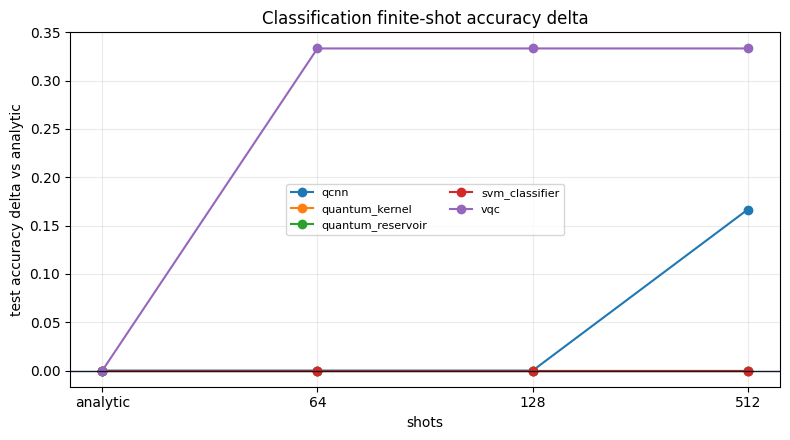

In [6]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for model in sorted({row["model"] for row in classification_summary}):
    rows = [row for row in classification_summary if row["model"] == model]
    ax.plot([row["shots"] for row in rows], [row["accuracy_delta_vs_analytic"] for row in rows], marker="o", label=model)
ax.axhline(0.0, color="#111827", linewidth=1)
ax.set_title("Classification finite-shot accuracy delta")
ax.set_ylabel("test accuracy delta vs analytic")
ax.set_xlabel("shots")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncols=2)
fig.tight_layout()
plt.show()


## Regression Shot Sweep

In [7]:
regression_summary = []

for shots in CONFIG["shot_values"]:
    result = compare_regression_models(
        models=[
            "vqr",
            "quantum_kernel_regressor",
            "quantum_gaussian_process_regressor",
            "quantum_reservoir_regressor",
            "ridge_regression",
        ],
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=CONFIG["regression_dataset"],
        model_kwargs={
            "vqr": {"n_layers": 1, "steps": 5, "shots": shots},
            "quantum_kernel_regressor": {"shots": shots},
            "quantum_gaussian_process_regressor": {"shots": shots},
            "quantum_reservoir_regressor": {"n_layers": 1, "shots": shots},
        },
        save=False,
    )
    regression_summary.extend(regression_rows(shots, result))

regression_summary = add_regression_degradation(regression_summary)
print_table(regression_summary, title="Regression finite-shot summary")

Regression finite-shot summary
+----------+------------------------------------+----------+----------+-----------+--------------------+------------+-----------------------+
| shots    | model                              | test_mse | ci95_low | ci95_high | generalization_gap | runtime_s  | mse_delta_vs_analytic |
+----------+------------------------------------+----------+----------+-----------+--------------------+------------+-----------------------+
| analytic | vqr                                | 0.665687 | 0.665687 | 0.665687  | -0.0945696         | 0.688634   | 0                     |
| analytic | quantum_kernel_regressor           | 0.618937 | 0.618937 | 0.618937  | 0.39149            | 0.474838   | 0                     |
| analytic | quantum_gaussian_process_regressor | 1.13144  | 1.13144  | 1.13144   | 1.06286            | 0.496159   | 0                     |
| analytic | quantum_reservoir_regressor        | 0.982325 | 0.982325 | 0.982325  | 0.100131           | 0.150744   |

## Regression Shot-Degradation Plot

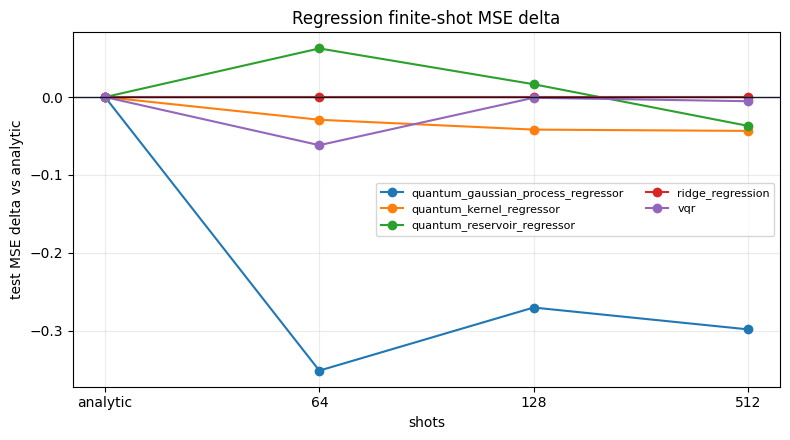

In [8]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for model in sorted({row["model"] for row in regression_summary}):
    rows = [row for row in regression_summary if row["model"] == model]
    ax.plot([row["shots"] for row in rows], [row["mse_delta_vs_analytic"] for row in rows], marker="o", label=model)
ax.axhline(0.0, color="#111827", linewidth=1)
ax.set_title("Regression finite-shot MSE delta")
ax.set_ylabel("test MSE delta vs analytic")
ax.set_xlabel("shots")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncols=2)
fig.tight_layout()
plt.show()
